<h1><font color="#113D68" size=5>Redes neuronales y deep learning</font></h1>



<h1><font color="#113D68" size=6>Actividad Semana 2</font></h1>


<br><br>
<div style="text-align: right">
<font size=3>Daniel González</font><br>
<font size=3>Semana 2: Frameworks de Deep Learning: TensorFlow</font><br>
<font size=3>IEBS</font>
</div>

---


In [2]:
import tensorflow as tf
import numpy as np

# Para mostrar gráficas
import matplotlib.pyplot as plt
%matplotlib inline

# Anaconda fixing problem
# import os
# os.environ['KMP_DUPLICATE_LIB_OK']='True' #Esta no es la solución optima, pero es la más rápida para evitar el error de duplicación de librerías de Anaconda
# En el propio mensaje de error indica que esta no es la mejor solución, puede arreglarse buscando la ubicación del fichero y eliminando la duplicación de librerías.
# Hecho

En esta actividad vamos a seguir familiarizándonos con la herramienta *TensorFlow*, para ello vamos a utilizar un dataset donde tendréis que relizar todos los pasos (cargar datos, crear arquitectura de la red, etc.) vosotros mismos para prácticar con la sintásis de *TensorFlow*. Tendéis ejercicios obligatorio y un ejercicio opcional.

# <font color="#004D7F" size=5>Ejercicio</font>
Usando los datos visto en los ejercicios sobre casa y sus precios realiza los ejercicios que se indican.

La información de los datos podéis verla en este enlace:

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/boston_housing/load_data

## <font color="#004D7F" size=4>Ejercicio 1</font>
Carga los datos como hemos visto en el notebook de los ejercicios donde tengas los conjuntos de train y test:

In [3]:
# Cargamos los datos de Boston Housing

(train_data, train_targets), (test_data, test_targets) = tf.keras.datasets.boston_housing.load_data()

Explora los tamaños de cada conjunto:

In [4]:
# Comprobamos el shape de los datos
print("train_data shape: ", train_data.shape)
print("train_targets shape: ", train_targets.shape)
print("test_data shape: ", test_data.shape)
print("test_targets shape: ", test_targets.shape)


train_data shape:  (404, 13)
train_targets shape:  (404,)
test_data shape:  (102, 13)
test_targets shape:  (102,)


## <font color="#004D7F" size=4>Ejercicio 2</font>
Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.
    - Tipo de entrenamiento:
        - *Epochs*: 100
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001
        - *Función de error*: error cuadrático medio (*mean_squared_error*)

In [5]:
# Importamos las capas que vamos a necesitar
from tensorflow.keras.layers import Dense, InputLayer

# Importamos las métricas que vamos a utilizar
from tensorflow.keras.metrics import MeanAbsoluteError, MeanSquaredError

# Creamos la arquitectura del modelo

model = tf.keras.Sequential()

model.add(InputLayer(input_shape=(train_data.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation=None))

# Definimos el optimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compilamos el modelo
model.compile(optimizer= opt, loss='mse', metrics=['mae'])

print(model.summary())


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 8)                 112       
_________________________________________________________________
dense_1 (Dense)              (None, 8)                 72        
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 9         
Total params: 193
Trainable params: 193
Non-trainable params: 0
_________________________________________________________________
None


In [6]:
history = model.fit(train_data, train_targets, epochs=100, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/100
11/11 [==============================] - 0s 7ms/step - loss: 7861.9692 - mae: 85.1913 - val_loss: 5844.1201 - val_mae: 74.0269
Epoch 2/100
11/11 [==============================] - 0s 815us/step - loss: 4645.9756 - mae: 65.4292 - val_loss: 3040.8489 - val_mae: 53.2903
Epoch 3/100
11/11 [==============================] - 0s 832us/step - loss: 2130.5098 - mae: 43.5894 - val_loss: 910.0286 - val_mae: 27.7178
Epoch 4/100
11/11 [==============================] - 0s 817us/step - loss: 472.3224 - mae: 18.3717 - val_loss: 130.5142 - val_mae: 9.0214
Epoch 5/100
11/11 [==============================] - 0s 839us/step - loss: 238.5125 - mae: 12.1367 - val_loss: 239.9151 - val_mae: 12.3495
Epoch 6/100
11/11 [==============================] - 0s 839us/step - loss: 199.5659 - mae: 11.1201 - val_loss: 114.8764 - val_mae: 8.4287
Epoch 7/100
11/11 [==============================] - 0s 812us/step - loss: 134.9987 - mae: 9.5573 - val_loss: 104.1913 - val_mae: 8.3075
Epoch 8/100
11/11 [=========

Evalúa el modelo usando la función *evaluate* para el conjunto de test:

4/4 [==============================] - 0s 388us/step - loss: 46.3784 - mae: 4.9249
Resultados del modelo
MSE:  46.378421783447266
MAE:  4.924881458282471
Gráfica de evolución del entrenamiento


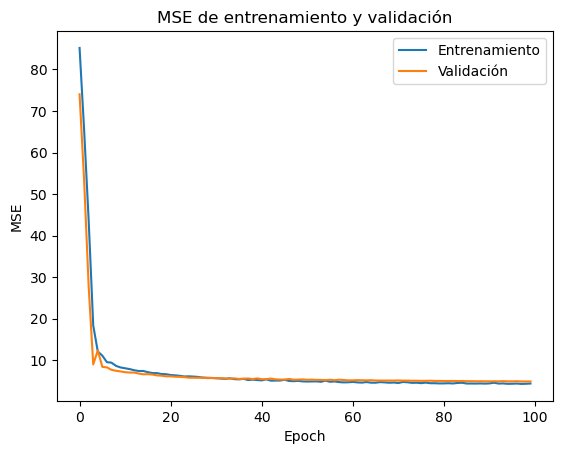

4/4 [==============================] - 0s 371us/step - loss: 46.3784 - mae: 4.9249


In [27]:
# Guardamos todos los resultados
resultados = []

# Vamos a evaluar el modelo
resultado = model.evaluate(test_data, test_targets, verbose=1)
print('Resultados del modelo')
print('MSE: ', resultado[0])
print('MAE: ', resultado[1])

resultados.append(resultado)

# Representamos los resultados en una gráfica
print('Gráfica de evolución del entrenamiento')
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('MSE de entrenamiento y validación')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
plt.show()


# Vamos a evaluar el modelo
resultado = model.evaluate(test_data, test_targets, verbose=1)


## <font color="#004D7F" size=4>Ejercicio 3</font>
Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.   
    - Tipo de entrenamiento:
        - *Epochs*: 300
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.0001
        - *Función de error*: error cuadrático medio (*mean_squared_error*)

In [8]:
# Establecemos la arquitectura del modelo

model2 = tf.keras.Sequential()
model2.add(InputLayer(input_shape=(train_data.shape[1],)))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1, activation=None))

print(model2.summary())

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 16)                224       
_________________________________________________________________
dense_4 (Dense)              (None, 16)                272       
_________________________________________________________________
dense_5 (Dense)              (None, 32)                544       
_________________________________________________________________
dense_6 (Dense)              (None, 1)                 33        
Total params: 1,073
Trainable params: 1,073
Non-trainable params: 0
_________________________________________________________________
None


In [9]:
# Definimos el optimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Entrenamos el modelo
model2.compile(optimizer='adam', loss='mse', metrics=['mae'])
history2 = model2.fit(train_data, train_targets, validation_split=0.2, epochs=300, batch_size=32, verbose=1)

Epoch 1/300
11/11 [==============================] - 0s 5ms/step - loss: 4493.1099 - mae: 61.5582 - val_loss: 1678.6616 - val_mae: 36.3137
Epoch 2/300
11/11 [==============================] - 0s 877us/step - loss: 958.6716 - mae: 26.1317 - val_loss: 303.7345 - val_mae: 13.7441
Epoch 3/300
11/11 [==============================] - 0s 835us/step - loss: 190.9481 - mae: 10.3596 - val_loss: 127.6528 - val_mae: 8.8821
Epoch 4/300
11/11 [==============================] - 0s 803us/step - loss: 123.8575 - mae: 8.4507 - val_loss: 137.5871 - val_mae: 8.4518
Epoch 5/300
11/11 [==============================] - 0s 828us/step - loss: 93.3730 - mae: 6.8823 - val_loss: 80.1748 - val_mae: 6.4554
Epoch 6/300
11/11 [==============================] - 0s 871us/step - loss: 71.8648 - mae: 6.5253 - val_loss: 76.5824 - val_mae: 6.3038
Epoch 7/300
11/11 [==============================] - 0s 821us/step - loss: 66.1508 - mae: 5.7534 - val_loss: 80.3581 - val_mae: 5.8131
Epoch 8/300
11/11 [=======================

Evalúa el modelo usando la función *evaluate* para el conjunto de test:

4/4 [==============================] - 0s 127us/step - loss: 29.4325 - mae: 3.8375
Resultados del modelo
MSE:  29.432506561279297
MAE:  3.8375067710876465
Gráfica de evolución del entrenamiento


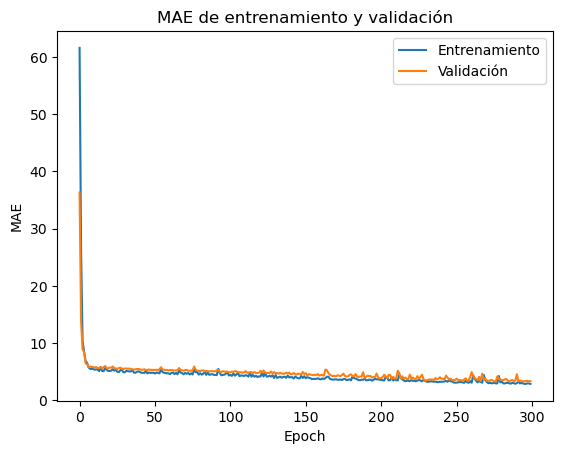

In [28]:
# Vamos a evaluar el modelo
resultado2 = model2.evaluate(test_data, test_targets, verbose=1)
print('Resultados del modelo')
print('MSE: ', resultado2[0])
print('MAE: ', resultado2[1])

resultados.append(resultado2)

# Representamos los resultados en una gráfica
print('Gráfica de evolución del entrenamiento')
plt.plot(history2.history['mae'])
plt.plot(history2.history['val_mae'])
plt.title('MAE de entrenamiento y validación')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
plt.show()

## <font color="#004D7F" size=4>Ejercicio 4</font>
Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 64 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 128 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.   
    - Tipo de entrenamiento:
        - *Epochs*: 2OO
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001
        - *Función de error*: error cuadrático medio (*mean_squared_error*)

In [11]:
# Establecemos la arquitectura del modelo

model3 = tf.keras.Sequential()
model3.add(InputLayer(input_shape=(train_data.shape[1],)))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(64, activation='relu'))
model3.add(Dense(128, activation='relu'))
model3.add(Dense(1, activation=None))

print(model3.summary())

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_7 (Dense)              (None, 32)                448       
_________________________________________________________________
dense_8 (Dense)              (None, 64)                2112      
_________________________________________________________________
dense_9 (Dense)              (None, 128)               8320      
_________________________________________________________________
dense_10 (Dense)             (None, 1)                 129       
Total params: 11,009
Trainable params: 11,009
Non-trainable params: 0
_________________________________________________________________
None


In [12]:
# Definimos el optimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

# Entrenamos el modelo
model3.compile(optimizer='adam', loss='mse', metrics=['mae'])
history3 = model3.fit(train_data, train_targets, validation_split=0.2, epochs=300, batch_size=32, verbose=1)

Epoch 1/300
11/11 [==============================] - 0s 5ms/step - loss: 2316.6843 - mae: 40.3142 - val_loss: 677.9618 - val_mae: 24.5617
Epoch 2/300
11/11 [==============================] - 0s 837us/step - loss: 337.7157 - mae: 15.2500 - val_loss: 254.4239 - val_mae: 13.9716
Epoch 3/300
11/11 [==============================] - 0s 902us/step - loss: 140.3169 - mae: 9.4143 - val_loss: 204.7887 - val_mae: 11.6289
Epoch 4/300
11/11 [==============================] - 0s 873us/step - loss: 97.9822 - mae: 7.1874 - val_loss: 82.0425 - val_mae: 7.4808
Epoch 5/300
11/11 [==============================] - 0s 846us/step - loss: 69.6464 - mae: 6.3824 - val_loss: 82.2720 - val_mae: 5.7711
Epoch 6/300
11/11 [==============================] - 0s 816us/step - loss: 62.6867 - mae: 5.0331 - val_loss: 69.8668 - val_mae: 5.8210
Epoch 7/300
11/11 [==============================] - 0s 886us/step - loss: 67.7368 - mae: 6.1946 - val_loss: 77.0194 - val_mae: 5.5523
Epoch 8/300
11/11 [==========================

Evalúa el modelo usando la función *evaluate* para el conjunto de test:

4/4 [==============================] - 0s 250us/step - loss: 30.2550 - mae: 3.7254
Resultados del modelo
MSE:  30.25501251220703
MAE:  3.72542405128479
Gráfica de evolución del entrenamiento


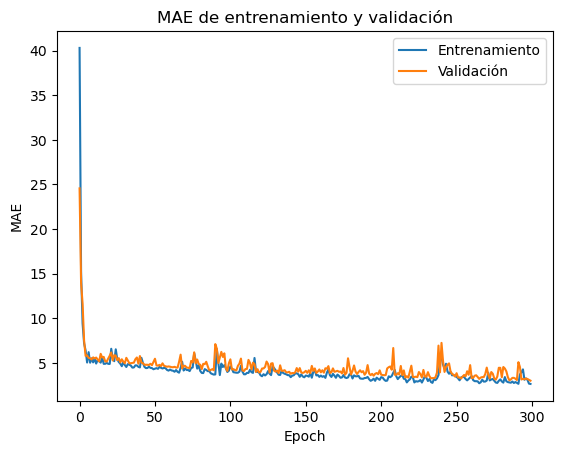

In [29]:
# Vamos a evaluar el modelo
resultado3 = model3.evaluate(test_data, test_targets, verbose=1)
print('Resultados del modelo')
print('MSE: ', resultado3[0])
print('MAE: ', resultado3[1])

resultados.append(resultado3)

# Representamos los resultados en una gráfica
print('Gráfica de evolución del entrenamiento')
plt.plot(history3.history['mae'])
plt.plot(history3.history['val_mae'])
plt.title('MAE de entrenamiento y validación')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
plt.show()

## <font color="#004D7F" size=4>Ejercicio 5</font>
Compara los resultados obtenidos en cada uno de los modelos entrenados y quédate con el mejor. **Justifica tu respuesta**.

El resultado no tiene porqué ser el mismo ya que los entrenamientos son aleatorios, pero un posible resultado podría ser este:

In [30]:
m = 0
for res in resultados:
    m+=1
    print('Modelo', m)
    print('MAE: ', res[1])
    print('MSE: ', res[0])
    print('-----------------------------------------')


Modelo 1
MAE:  4.924881458282471
MSE:  46.378421783447266
-----------------------------------------
Modelo 2
MAE:  3.8375067710876465
MSE:  29.432506561279297
-----------------------------------------
Modelo 3
MAE:  3.72542405128479
MSE:  30.25501251220703
-----------------------------------------


In [36]:
print(np.sqrt(resultados[1][0]))
print(np.sqrt(resultados[2][0])) 

5.42517341301449
5.500455664052482


Atendiendo a las dos métricas evaluadas para cada una de las respectivas redes neuronales, podemos decir que los mejores modelos son los dos últimos, obteniendo unos resultados de ambas métricas muy parejos. Si bien es cierto que debido a la superior velocidad de aprendizaje, el tercer modelo presenta mayor variabilidad a lo largo de las épocas, mientras que el segundo es más estable, aunque también cabe señalar que el tercero se entrena en menor tiempo. Sin embargo, dada la sencillez de los datos, es preferible el modelo con un resultado más estable a lo largo de su entrenamiento, dado que será menos probable que haya dado con un mínimo local. Por lo tanto, de tener que elegir un único modelo, me quedaría con el segundo.

Además guarda el mejor modelo en formato *.h5* usando la función `save`:

In [37]:
# Guardamos el segundo modelo
model2.save('modelo2.h5')

## <font color="#004D7F" size=4>Ejercicio 6 (Opcional)</font>
Carga el mejor modelo que has guardado en el ejercicio anterior usando la función `load_model` y realizar predicciones usando la función `predict`.

Para realizar las predicciones usa 10 datos cualquier del conjunto de test:

In [41]:
# Cargamos el modelo guardado
model_ld = tf.keras.models.load_model('modelo2.h5')

# Realizamos predicciones de nuevos datos
x_new = np.random.rand(20, train_data.shape[1])
y_pred = model_ld.predict(x_new)

print('Predicción de nuevos datos: ', y_pred)

Predicción de nuevos datos:  [[0.5824767 ]
 [1.0708668 ]
 [1.7522502 ]
 [2.2568958 ]
 [1.3008785 ]
 [0.8807466 ]
 [1.1012805 ]
 [0.36870557]
 [2.0556335 ]
 [1.7277572 ]
 [0.681779  ]
 [1.4446696 ]
 [0.35884345]
 [1.6979383 ]
 [0.44243142]
 [0.5294796 ]
 [2.3773565 ]
 [0.86896217]
 [2.0282762 ]
 [0.8234811 ]]
